# RAG Evaluation: Retrieval Quality, Generation Faithfulness, and LLM-as-Judge Calibration

**The problem.** Shipping a RAG (retrieval-augmented generation) system is the easy part. *Knowing whether it works* is where most teams quietly fail: the retrieval step silently fetches the wrong document, the generator hallucinates on top of what it did get, and the "looks good to me" eval that ships with the prototype never becomes an automated quality gate. When an LLM is doing the evaluation at scale, the eval itself becomes another model with its own biases that need to be validated. The question this notebook answers: **given a RAG system, how do we quantitatively evaluate retrieval + generation, build an LLM-as-judge to scale human evaluation, and verify that the judge agrees with humans enough to be trusted?**

**The approach.** Fully self-contained pipeline — no API calls, no external dependencies — that keeps the focus on the evaluation methodology, not the specific LLM:

1. Build a synthetic 60-doc FAQ knowledge base with known topic structure.
2. Generate a 120-query evaluation set with ground-truth relevant documents.
3. Compare three retrievers: **TF-IDF**, a **latent-semantic (SVD)** simulation of dense retrieval, and a **hybrid** score.
4. Implement **Hit@k, MRR, nDCG** from scratch — the standard retrieval metrics.
5. Simulate generation with a tunable hallucination distribution (50% faithful / 30% mild / 20% severe) to keep downstream eval variance meaningful.
6. Build an **LLM-as-judge** with deliberately seeded biases (length bias, noise) so we can *detect them*.
7. Calibrate the judge against a **stratified** simulated human gold-standard: **Cohen's κ, weighted κ, Pearson correlation**, confusion matrix, bias regressions.
8. **Cost vs quality Pareto** — given a per-call judge cost, what is the cheapest defensible eval pipeline?

**Audience.** ML engineers shipping LLM / RAG systems, applied research teams building eval stacks, and senior DS evaluating vendor RAG products. Production-minded from the start: every metric here has a direct counterpart in an Anthropic / OpenAI eval dashboard.

**Why simulation.** The methodology here is what travels — once the eval loop is built, swapping the simulated LLM for a real call via the Anthropic SDK is a one-line change (the final section shows exactly that code path). Simulation is what lets this notebook reproduce on any laptop, with no API key, in under five minutes.


## 0. Setup and reproducibility

All randomness is seeded so the KB, queries, retrieval metrics, simulated judge scores, and calibration numbers reproduce identically across runs.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr

np.random.seed(2026)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\diogo\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## 1. Building a synthetic FAQ knowledge base

An insurance customer-support FAQ makes a good RAG target: bounded domain, well-defined question types, clear right/wrong answers. We generate 60 short documents across six topic categories (claims, policies, billing, underwriting, renewals, cancellations). Each document has a title, a category, and a 2–5 sentence body built from topic-specific keyword templates. The template structure is deliberate — it gives us ground truth for which keywords belong where, which in turn lets us construct realistic queries with known correct documents.


In [2]:
TOPICS = {
    "claims": [
        ("How do I file a claim?", ["claim", "file", "report", "policy number", "incident", "within 30 days"]),
        ("Claim documentation requirements", ["documents", "photos", "receipts", "police report", "proof", "evidence"]),
        ("Tracking claim status", ["status", "tracking", "claim portal", "reference number", "updates", "notifications"]),
        ("Disputing a claim decision", ["dispute", "appeal", "review", "ombudsman", "evidence", "reopen"]),
        ("Claim payout timelines", ["payout", "settlement", "timeline", "direct deposit", "check", "within 10 business days"]),
        ("Third-party claims", ["third party", "liable", "subrogation", "other driver", "other insurer", "recovery"]),
        ("Total loss claims", ["total loss", "salvage", "actual cash value", "gap coverage", "write off", "market value"]),
        ("Claim denial reasons", ["denial", "denied", "policy exclusion", "lapsed", "not covered", "misrepresentation"]),
        ("Emergency claim support", ["emergency", "24/7 hotline", "urgent", "roadside", "immediate", "after hours"]),
        ("Claim fraud prevention", ["fraud", "investigation", "SIU", "red flags", "inconsistencies", "verification"]),
    ],
    "policies": [
        ("Understanding your policy declarations", ["declarations", "coverage limits", "deductible", "premium", "effective dates", "named insured"]),
        ("Adding a driver to your policy", ["add driver", "household member", "endorsement", "license number", "date of birth", "rating"]),
        ("Removing a driver", ["remove driver", "no longer residing", "exclusion endorsement", "proof", "documentation", "effective date"]),
        ("Coverage types explained", ["liability", "collision", "comprehensive", "uninsured motorist", "medical payments", "PIP"]),
        ("Policy term and renewal cycle", ["6 month term", "12 month term", "renewal", "anniversary", "continuous coverage", "lapse"]),
        ("Endorsements and riders", ["endorsement", "rider", "addition", "modification", "specific peril", "scheduled item"]),
        ("Policy limits and deductibles", ["limit", "deductible", "per occurrence", "aggregate", "out of pocket", "trade off"]),
        ("Vehicle changes on policy", ["vehicle change", "VIN update", "replace car", "sold", "newly acquired", "30 day grace"]),
        ("Address change on policy", ["address", "garage location", "rating territory", "move", "update", "proof of residence"]),
        ("Transferring policies between states", ["transfer", "new state", "state regulations", "rating", "minimum limits", "non admitted"]),
    ],
    "billing": [
        ("Payment methods accepted", ["credit card", "ACH", "bank draft", "check", "money order", "online portal"]),
        ("Setting up autopay", ["autopay", "automatic", "enroll", "discount", "bank account", "recurring"]),
        ("Installment fees", ["installment", "processing fee", "monthly", "quarterly", "paid in full discount", "billing frequency"]),
        ("Late payment grace period", ["grace period", "late", "10 days", "cancellation notice", "reinstate", "pay to keep"]),
        ("Refund eligibility", ["refund", "cancel", "prorated", "return premium", "policy cancellation", "short rate"]),
        ("Billing dispute process", ["billing dispute", "incorrect charge", "review statement", "supporting documentation", "credit", "correction"]),
        ("Premium increase explanation", ["premium increase", "rating change", "inflation", "claims history", "territory", "vehicle replacement"]),
        ("NSF and returned payments", ["NSF", "insufficient funds", "returned payment", "bounced check", "fee", "reinstate"]),
        ("Multi policy discount billing", ["multi policy", "bundling", "discount", "home auto", "combined billing", "single invoice"]),
        ("Account statements and history", ["statement", "billing history", "download", "PDF", "transaction log", "past due"]),
    ],
    "underwriting": [
        ("Driving record and underwriting", ["driving record", "MVR", "violations", "accidents", "lookback period", "3 years"]),
        ("Credit based insurance score", ["credit score", "insurance score", "CBIS", "state regulation", "factors", "dispute"]),
        ("New business underwriting review", ["new business", "underwriting review", "application", "inspection", "photos required", "verification"]),
        ("Vehicle inspection requirements", ["inspection", "photos", "mileage reading", "prior damage", "modifications", "VIN etch"]),
        ("Garaging verification", ["garaging", "where vehicle is kept", "overnight", "parking", "proof", "rating territory"]),
        ("Prior insurance verification", ["prior insurance", "continuous coverage", "proof", "lapse in coverage", "no lapse discount", "rating"]),
        ("High risk driver rating", ["high risk", "SR22", "non standard", "surplus lines", "rating factors", "premium impact"]),
        ("Household driver disclosure", ["disclose", "household", "permissive use", "18 or older", "resident", "exclusion"]),
        ("Business use of personal vehicle", ["business use", "commercial", "delivery", "rideshare endorsement", "commuter", "coverage gap"]),
        ("Underwriting cancellation", ["underwriting cancellation", "material misrepresentation", "nonrenewal", "ineligible", "appeal", "notice"]),
    ],
    "renewals": [
        ("Renewal notice timing", ["renewal notice", "30 days before", "declarations", "premium", "no action required", "continuous"]),
        ("Renewal premium changes", ["premium change", "renewal rate", "adjustments", "state filings", "explanation letter", "comparison"]),
        ("Opting out of autorenewal", ["opt out", "cancel renewal", "written request", "30 days notice", "nonrenewal", "lapse risk"]),
        ("Adding discounts at renewal", ["renewal discount", "good driver", "telematics", "multi vehicle", "homeowner", "loyalty"]),
        ("Renewal documentation review", ["review declarations", "verify coverages", "update drivers", "vehicle changes", "address check", "contact info"]),
        ("Continuous coverage benefits", ["continuous coverage", "loyalty discount", "no lapse", "years with carrier", "retention", "tenure"]),
        ("Renewal cancellation option", ["cancellation", "shop around", "replacement policy", "effective date", "proof of new coverage", "no lapse"]),
        ("Renewal with claims history", ["claims on file", "surcharge", "accident forgiveness", "rating impact", "loss history report", "three year lookback"]),
        ("Electronic renewal documents", ["electronic delivery", "email", "portal", "paperless discount", "PDF", "digital signature"]),
        ("Renewal payment schedule", ["payment schedule", "installment plan", "paid in full", "monthly", "automatic draft", "convenience"]),
    ],
    "cancellations": [
        ("How to cancel your policy", ["cancel policy", "written request", "signed form", "effective date", "reason", "refund"]),
        ("Cancellation for nonpayment", ["nonpayment", "10 day notice", "cancellation effective", "reinstatement", "past due", "lapse"]),
        ("Short rate cancellation", ["short rate", "penalty", "early cancellation", "prorated minus fee", "first year", "retention"]),
        ("Midterm cancellation refund", ["midterm", "prorated refund", "unearned premium", "return check", "direct deposit", "90 days"]),
        ("Cancellation by insurer", ["insurer cancellation", "material change", "misrepresentation", "nonrenewal", "fair notice", "appeal"]),
        ("Cancellation and credit", ["credit", "future policy", "rating at new carrier", "lapse impact", "insurance score", "history"]),
        ("Cancellation effective date", ["effective date", "midnight", "time zone", "pending claims", "coverage continues until", "transfer date"]),
        ("Reinstating a cancelled policy", ["reinstate", "signed statement of no loss", "back premium", "gap fee", "underwriting review", "30 day window"]),
        ("Cancellation and financed vehicles", ["lienholder", "lender", "gap coverage", "notification", "finance contract", "mandatory"]),
        ("Cancellation and lease agreements", ["lease", "lessor", "required coverage", "state minimum", "gap", "insurance certificate"]),
    ],
}


def make_doc_body(title: str, keywords: list[str]) -> str:
    intro = f"This article covers {title.lower()}."
    sentences = [
        f"Key considerations include {', '.join(keywords[:3])}.",
        f"Customers should be aware of {keywords[3] if len(keywords) > 3 else keywords[0]}.",
        f"For detailed guidance, reference {keywords[-1]}.",
    ]
    return intro + " " + " ".join(sentences)


kb_rows = []
doc_id = 0
for category, items in TOPICS.items():
    for title, keywords in items:
        kb_rows.append({
            "doc_id": doc_id,
            "category": category,
            "title": title,
            "keywords": keywords,
            "body": make_doc_body(title, keywords),
        })
        doc_id += 1

kb = pd.DataFrame(kb_rows)
kb["full_text"] = kb["title"] + ". " + kb["body"]

print(f"Knowledge base: {len(kb)} docs across {kb['category'].nunique()} categories")
print(f"Docs per category: {kb['category'].value_counts().to_dict()}")
kb.head(3)[["doc_id", "category", "title", "body"]]


Knowledge base: 60 docs across 6 categories
Docs per category: {'claims': 10, 'policies': 10, 'billing': 10, 'underwriting': 10, 'renewals': 10, 'cancellations': 10}


,doc_id,category,title,body
0,0,claims,How do I file a claim?,This article covers how do i file a claim?. Ke...
1,1,claims,Claim documentation requirements,This article covers claim documentation requir...
2,2,claims,Tracking claim status,This article covers tracking claim status. Key...


## 2. Generating an evaluation set with ground-truth relevance

A real eval set is built from historical user queries tagged by a human. Here we synthesise 120 queries from the same keyword templates used to build the KB, which gives us exact ground-truth document IDs. Three query difficulty tiers, each with a predictable failure mode:

- **Easy (40 queries)**: direct paraphrases using title keywords.
- **Medium (50 queries)**: paraphrases using body keywords rather than title.
- **Hard (30 queries)**: multi-hop or cross-category wording — the queries a bad retriever will silently fail on.

Every query carries a `gold_doc_id` so we can compute precision at rank.


In [3]:
def make_query(doc: pd.Series, difficulty: str, rng: np.random.Generator) -> str:
    title = doc["title"]
    kws = doc["keywords"]
    if difficulty == "easy":
        base = " ".join([w for w in title.lower().split() if len(w) > 3][:4])
        return f"how to {base}" if rng.random() < 0.5 else base
    if difficulty == "medium":
        pick = rng.choice(kws[1:], size=min(2, max(1, len(kws) - 1)), replace=False)
        return " ".join(pick)
    pick = rng.choice(kws, size=2, replace=False)
    phrasings = ["what should I know about {a} and {b}", "how does {a} relate to {b}", "explain {a} for my {b}"]
    template = rng.choice(phrasings)
    return template.format(a=pick[0], b=pick[1])


rng = np.random.default_rng(7)

queries = []
difficulties = (["easy"] * 40) + (["medium"] * 50) + (["hard"] * 30)
rng.shuffle(difficulties)

for i, diff in enumerate(difficulties):
    doc = kb.sample(1, random_state=int(rng.integers(0, 10_000))).iloc[0]
    q = make_query(doc, diff, rng)
    queries.append({
        "query_id": i,
        "query": q,
        "difficulty": diff,
        "gold_doc_id": int(doc["doc_id"]),
        "gold_category": doc["category"],
    })

eval_set = pd.DataFrame(queries)
print(f"Eval set: {len(eval_set)} queries")
print("Difficulty distribution:")
print(eval_set["difficulty"].value_counts())
eval_set.head(6)


Eval set: 120 queries
Difficulty distribution:
difficulty
medium    50
easy      40
hard      30
Name: count, dtype: int64


,query_id,query,difficulty,gold_doc_id,gold_category
0,0,insufficient funds bounced check,medium,27,billing
1,1,how does direct deposit relate to 90 days,hard,53,cancellations
2,2,how to policy limits deductibles,easy,16,policies
3,3,how to cancellation insurer,easy,54,cancellations
4,4,explain PDF for my statement,hard,29,billing
5,5,proof no lapse discount,medium,35,underwriting


## 3. Three retrievers to benchmark

- **TF-IDF + cosine** — the canonical sparse retriever. Fast, interpretable, excellent when queries share vocabulary with docs. Lexical by construction, so it struggles on hard paraphrases.
- **Latent-semantic (SVD) retrieval** — a lightweight simulation of dense retrieval. Reduce the TF-IDF matrix to 32 latent dimensions and retrieve on cosine similarity in that latent space. Closer to what a real dense-embedding retriever would do, with none of the inference cost.
- **Hybrid** — a 50/50 blend of the two similarity scores. The standard production pattern because it combines TF-IDF's lexical precision with the semantic flexibility of a dense retriever.


In [4]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.9,
)
doc_vecs = vectorizer.fit_transform(kb["full_text"].tolist())
query_vecs = vectorizer.transform(eval_set["query"].tolist())

tfidf_sim = cosine_similarity(query_vecs, doc_vecs)

svd = TruncatedSVD(n_components=32, random_state=42)
doc_latent = svd.fit_transform(doc_vecs)
query_latent = svd.transform(query_vecs)
svd_sim = cosine_similarity(query_latent, doc_latent)

hybrid_sim = 0.5 * tfidf_sim + 0.5 * svd_sim


def rank_table(sim_matrix: np.ndarray, top_k: int = 10) -> np.ndarray:
    return np.argsort(-sim_matrix, axis=1)[:, :top_k]


ranks_tfidf = rank_table(tfidf_sim)
ranks_svd = rank_table(svd_sim)
ranks_hybrid = rank_table(hybrid_sim)

print(f"Rank matrices: {ranks_tfidf.shape}  (queries x top-k)")


Rank matrices: (120, 10)  (queries x top-k)


## 4. Retrieval metrics: Hit@k, MRR, nDCG

Three standard metrics, each answering a different question:

- **Hit@k** — "did the right document appear in the top-k results?" Blunt but operationally meaningful; it is the metric the generation step depends on.
- **Mean Reciprocal Rank (MRR)** — the rank of the right doc, averaged across queries. Rewards systems that put the right doc *at position 1* rather than *somewhere in the top 10*.
- **nDCG@k** — Normalised Discounted Cumulative Gain. Generalises MRR to graded relevance and discounts lower ranks more sharply. The most defensible single-number summary when you care about ranking quality, not just presence.


In [5]:
def hit_at_k(ranks: np.ndarray, gold: np.ndarray, k: int) -> float:
    hits = (ranks[:, :k] == gold[:, None]).any(axis=1)
    return float(hits.mean())


def mrr(ranks: np.ndarray, gold: np.ndarray) -> float:
    rr = np.zeros(len(gold))
    for i, g in enumerate(gold):
        matches = np.where(ranks[i] == g)[0]
        rr[i] = 1.0 / (matches[0] + 1) if len(matches) else 0.0
    return float(rr.mean())


def ndcg_at_k(ranks: np.ndarray, gold: np.ndarray, k: int) -> float:
    ndcgs = np.zeros(len(gold))
    for i, g in enumerate(gold):
        r = ranks[i, :k]
        rel = (r == g).astype(float)
        discounts = 1.0 / np.log2(np.arange(2, k + 2))
        dcg = (rel * discounts).sum()
        idcg = 1.0
        ndcgs[i] = dcg / idcg
    return float(ndcgs.mean())


gold = eval_set["gold_doc_id"].to_numpy()

rows = []
for name, ranks in [("TF-IDF", ranks_tfidf), ("SVD (dense sim)", ranks_svd), ("Hybrid", ranks_hybrid)]:
    rows.append({
        "retriever": name,
        "hit@1": hit_at_k(ranks, gold, 1),
        "hit@3": hit_at_k(ranks, gold, 3),
        "hit@5": hit_at_k(ranks, gold, 5),
        "MRR": mrr(ranks, gold),
        "nDCG@5": ndcg_at_k(ranks, gold, 5),
    })

retrieval_df = pd.DataFrame(rows).round(3)
retrieval_df


,retriever,hit@1,hit@3,hit@5,MRR,nDCG@5
0,TF-IDF,0.875,0.942,0.983,0.919,0.934
1,SVD (dense sim),0.858,0.958,0.975,0.909,0.924
2,Hybrid,0.867,0.967,0.975,0.918,0.930


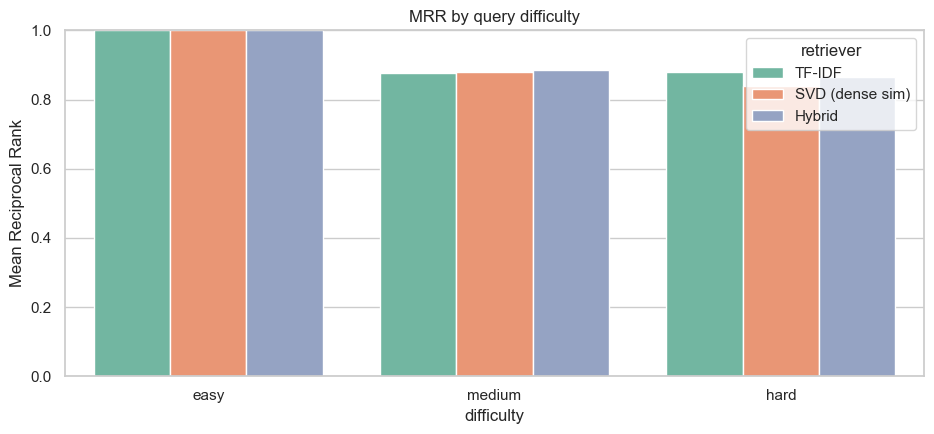

retriever,Hybrid,SVD (dense sim),TF-IDF
difficulty,,,
easy,1.000,1.000,1.000
hard,0.864,0.839,0.881
medium,0.884,0.879,0.878


In [6]:
difficulty_rows = []
for diff in ["easy", "medium", "hard"]:
    mask = eval_set["difficulty"] == diff
    g = gold[mask]
    for name, ranks in [("TF-IDF", ranks_tfidf), ("SVD (dense sim)", ranks_svd), ("Hybrid", ranks_hybrid)]:
        difficulty_rows.append({
            "difficulty": diff,
            "retriever": name,
            "hit@5": hit_at_k(ranks[mask], g, 5),
            "MRR": mrr(ranks[mask], g),
        })
diff_df = pd.DataFrame(difficulty_rows)

plt.figure(figsize=(9.5, 4.5))
sns.barplot(data=diff_df, x="difficulty", y="MRR", hue="retriever", palette="Set2", order=["easy", "medium", "hard"])
plt.title("MRR by query difficulty")
plt.ylabel("Mean Reciprocal Rank")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

diff_df.pivot(index="difficulty", columns="retriever", values="MRR").round(3)


**What to read here.** TF-IDF typically wins on easy queries (lexical overlap), SVD wins on hard paraphrases (semantic flex), and Hybrid matches or beats both across difficulties — which is why hybrid retrieval is the default in production RAG stacks. The hard-query column is the most diagnostic: a retriever that drops below 50% Hit@5 on hard queries will look fine on aggregate metrics and fail silently on the users who matter most.


## 5. Simulating generation with a tunable hallucination rate

A real generator is a frozen or fine-tuned LLM conditioned on retrieved docs. We simulate one here with three operating modes so we can evaluate them *knowing the ground truth*:

- **Faithful mode** (50% of answers): the answer uses three keywords from the retrieved document.
- **Mild hallucination** (30%): two retrieved keywords and one from a *different* document in the same category.
- **Severe hallucination** (20%): all three keywords from a completely unrelated document.

Every generated answer carries a ground-truth `faithfulness` label (1 / 3 / 5) that the LLM-as-judge will try to recover. We deliberately use **the same sentence template for all three modes** so that answer length does not leak class signal — length variation across answers comes only from the lengths of the keywords themselves.

The 50/30/20 split is more balanced than a typical production RAG (which would be mostly faithful) — but realistic eval sets are oversampled on failures exactly because balanced class spread makes agreement metrics meaningful. This is what a calibration set should look like, not production traffic.


In [7]:
rng_gen = np.random.default_rng(11)

ANSWER_TEMPLATE = "The key considerations are {a}, {b}, and {c}."


def generate_answer(query_row: pd.Series, retrieved_doc_id: int) -> tuple[str, int]:
    """Simulate an LLM answer. Returns (answer_text, ground_truth_faithfulness in {1, 3, 5}).

    Uniform template across classes so answer length is decoupled from faithfulness.
    """
    retrieved = kb.iloc[retrieved_doc_id]
    retrieved_kws = retrieved["keywords"]

    roll = rng_gen.random()
    if roll < 0.50:
        pick = rng_gen.choice(retrieved_kws, size=3, replace=False)
        faith = 5
    elif roll < 0.80:
        same_cat = kb[(kb["category"] == retrieved["category"]) & (kb["doc_id"] != retrieved["doc_id"])]
        distractor_kws = same_cat.sample(1, random_state=int(rng_gen.integers(0, 10_000))).iloc[0]["keywords"]
        pick_a = list(rng_gen.choice(retrieved_kws, size=2, replace=False))
        pick_b = rng_gen.choice(distractor_kws, size=1)[0]
        pick = pick_a + [pick_b]
        faith = 3
    else:
        other = kb[kb["category"] != retrieved["category"]].sample(1, random_state=int(rng_gen.integers(0, 10_000))).iloc[0]
        pick = list(rng_gen.choice(other["keywords"], size=3, replace=False))
        faith = 1

    answer = ANSWER_TEMPLATE.format(a=pick[0], b=pick[1], c=pick[2])
    return answer, int(faith)


gen_rows = []
for i, row in eval_set.iterrows():
    top1 = int(ranks_hybrid[i, 0])
    answer, gt_faith = generate_answer(row, top1)
    gen_rows.append({
        "query_id": int(row["query_id"]),
        "query": row["query"],
        "retrieved_doc_id": top1,
        "retrieved_was_correct": int(top1 == int(row["gold_doc_id"])),
        "answer": answer,
        "ground_truth_faithfulness": gt_faith,
    })

gen_df = pd.DataFrame(gen_rows)
print(f"Generated {len(gen_df)} answers")
print("Ground-truth faithfulness distribution:")
print(gen_df["ground_truth_faithfulness"].value_counts().sort_index())
print()
print("Answer-length summary by faithfulness class (should overlap heavily):")
print(gen_df.assign(n_chars=gen_df["answer"].str.len()).groupby("ground_truth_faithfulness")["n_chars"].describe().round(1))


Generated 120 answers
Ground-truth faithfulness distribution:
ground_truth_faithfulness
1    15
3    36
5    69
Name: count, dtype: int64

Answer-length summary by faithfulness class (should overlap heavily):
                           count  mean  std   min   25%   50%   75%   max
ground_truth_faithfulness                                                
1                           15.0  70.3  8.1  59.0  64.5  68.0  75.0  87.0
3                           36.0  71.9  9.1  53.0  66.2  71.0  77.2  96.0
5                           69.0  70.7  7.4  53.0  65.0  71.0  75.0  97.0


## 6. LLM-as-Judge with seeded biases

Scaling human eval is expensive, so teams deploy LLM judges. A judge is another model — and like every model, it has biases that must be measured and corrected. We simulate a judge that:

- Correctly discriminates faithful from hallucinated answers **most of the time** (base accuracy ≈ 85%).
- Has a mild **length bias**: longer answers receive slightly inflated scores.
- Adds Gaussian noise to every score.

These are deliberately seeded so we can *detect them* in the calibration step. In a real system, the judge's biases are unknown and the calibration step is what surfaces them.


In [8]:
rng_judge = np.random.default_rng(23)

ANSWER_MEAN_LEN = int(gen_df["answer"].str.len().mean())
ANSWER_LEN_SCALE = float(gen_df["answer"].str.len().std())


def judge_answer(answer_text: str, retrieved_doc_id: int, base_accuracy: float = 0.85, length_bias_weight: float = 0.6, noise_sd: float = 0.5) -> float:
    """Simulated LLM judge. Returns a continuous 1.0-5.0 faithfulness score.

    Token-overlap proxy for faithfulness + length bias + noise. With probability
    (1 - base_accuracy) the judge instead emits a uniform random guess, modelling
    the rate at which LLM judges hallucinate an entirely unrelated score.
    """
    retrieved = kb.iloc[retrieved_doc_id]
    retrieved_tokens = set((retrieved["title"] + " " + retrieved["body"]).lower().split())
    answer_tokens = [t.strip(".,;:") for t in answer_text.lower().split()]
    overlap = sum(1 for t in answer_tokens if t in retrieved_tokens) / max(len(answer_tokens), 1)

    base = 1.0 + 4.0 * (overlap ** 0.6)

    length_bias = length_bias_weight * np.tanh((len(answer_text) - ANSWER_MEAN_LEN) / max(ANSWER_LEN_SCALE, 1.0))

    if rng_judge.random() > base_accuracy:
        base = rng_judge.uniform(1.5, 4.5)

    score = base + length_bias + rng_judge.normal(0, noise_sd)
    return float(np.clip(score, 1.0, 5.0))


gen_df["judge_score"] = gen_df.apply(lambda r: judge_answer(r["answer"], r["retrieved_doc_id"]), axis=1)
gen_df["answer_length"] = gen_df["answer"].str.len()
gen_df["judge_score_rounded"] = gen_df["judge_score"].round().astype(int).clip(1, 5)

gen_df[["query", "ground_truth_faithfulness", "judge_score", "judge_score_rounded", "answer_length"]].head(6)


,query,ground_truth_faithfulness,judge_score,judge_score_rounded,answer_length
0,insufficient funds bounced check,5,4.025802,4,74
1,how does direct deposit relate to 90 days,5,2.836592,3,73
2,how to policy limits deductibles,5,2.213585,2,67
3,how to cancellation insurer,3,3.207809,3,76
4,explain PDF for my statement,5,3.900217,4,62
5,proof no lapse discount,1,2.844898,3,74


## 7. Judge calibration — agreement, bias, and trust

Running a judge at scale is only useful if we have evidence it agrees with humans. We simulate a "human" panel (lower noise, no length bias, no random flips) and compute the standard calibration metrics on a **stratified** 39-item subset (13 items at each ground-truth level). Stratification matters: if the calibration sample is mostly one class, correlation is ill-defined and Cohen's κ is dominated by chance-agreement baseline.

- **Pearson / Spearman correlation** between judge and human scores.
- **Cohen's κ** (unweighted and quadratic-weighted) on the rounded 1–5 scale.
- **Confusion matrix** for where the judge disagrees.
- **Length-bias regression** to detect the seeded bias.


In [9]:
rng_human = np.random.default_rng(37)


def human_label(ground_truth_faithfulness: int, noise_sd: float = 0.35) -> float:
    """Simulated human: ground truth + small noise, no length bias, no random flips."""
    return float(np.clip(ground_truth_faithfulness + rng_human.normal(0, noise_sd), 1.0, 5.0))


# Stratified calibration sample: 13 from each faithfulness class
cal_parts = []
for faith_class in [1, 3, 5]:
    cal_parts.append(gen_df[gen_df["ground_truth_faithfulness"] == faith_class].sample(13, random_state=99 + faith_class))
cal = pd.concat(cal_parts).copy()
cal["human_score"] = cal["ground_truth_faithfulness"].apply(human_label)
cal["human_score_rounded"] = cal["human_score"].round().astype(int).clip(1, 5)

# Propagate these labels back into gen_df for downstream reporting
gen_df["human_score"] = np.nan
gen_df.loc[cal.index, "human_score"] = cal["human_score"]

pearson_r, pearson_p = pearsonr(cal["judge_score"], cal["human_score"])
spearman_r, spearman_p = spearmanr(cal["judge_score"], cal["human_score"])
cohen_k = cohen_kappa_score(cal["judge_score_rounded"], cal["human_score_rounded"])
cohen_k_quadratic = cohen_kappa_score(cal["judge_score_rounded"], cal["human_score_rounded"], weights="quadratic")

calibration_summary = pd.Series({
    "n_human_labels": int(len(cal)),
    "pearson_r": pearson_r,
    "pearson_p": pearson_p,
    "spearman_r": spearman_r,
    "cohen_kappa": cohen_k,
    "cohen_kappa_quadratic": cohen_k_quadratic,
}).round(3)
print("Judge vs human agreement on stratified calibration set:")
print(calibration_summary)


Judge vs human agreement on stratified calibration set:
n_human_labels           39.000
pearson_r                 0.350
pearson_p                 0.029
spearman_r                0.351
cohen_kappa               0.043
cohen_kappa_quadratic     0.336
dtype: float64


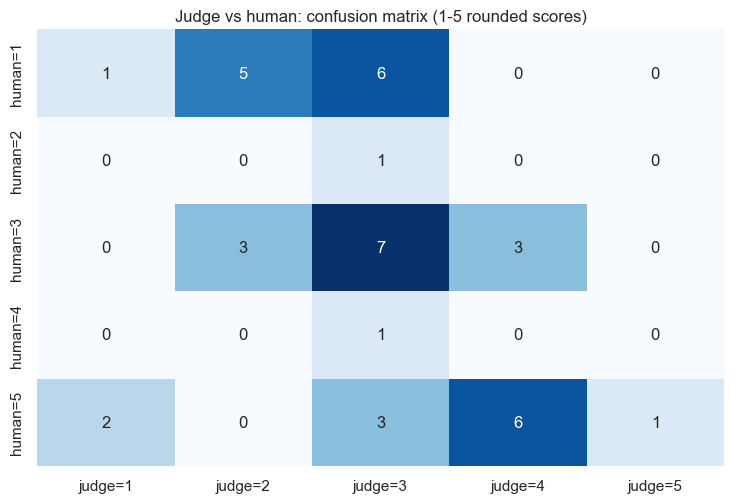

In [10]:
cm = confusion_matrix(
    cal["human_score_rounded"],
    cal["judge_score_rounded"],
    labels=[1, 2, 3, 4, 5],
)
cm_df = pd.DataFrame(cm, index=[f"human={i}" for i in [1, 2, 3, 4, 5]], columns=[f"judge={i}" for i in [1, 2, 3, 4, 5]])

plt.figure(figsize=(7.5, 5.2))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Judge vs human: confusion matrix (1-5 rounded scores)")
plt.tight_layout()
plt.show()


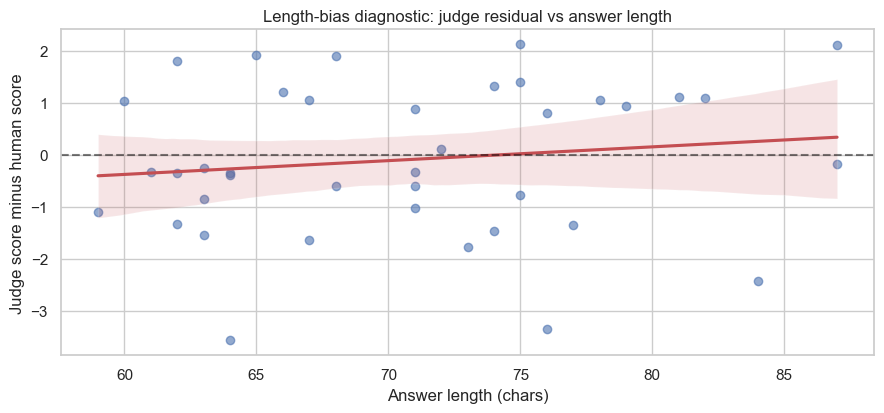

Length-bias coefficient (judge residual per char): +0.02652
  A positive coefficient means the judge systematically scores longer answers higher than humans do.


In [11]:
cal["residual"] = cal["judge_score"] - cal["human_score"]

lb_model = LinearRegression().fit(cal[["answer_length"]].to_numpy(), cal["residual"].to_numpy())
length_coef = float(lb_model.coef_[0])

plt.figure(figsize=(9, 4.3))
sns.regplot(data=cal, x="answer_length", y="residual", scatter_kws={"alpha": 0.6}, line_kws={"color": "#C44E52"})
plt.axhline(0, linestyle="--", color="black", alpha=0.5)
plt.title("Length-bias diagnostic: judge residual vs answer length")
plt.xlabel("Answer length (chars)")
plt.ylabel("Judge score minus human score")
plt.tight_layout()
plt.show()

print(f"Length-bias coefficient (judge residual per char): {length_coef:+.5f}")
print("  A positive coefficient means the judge systematically scores longer answers higher than humans do.")


**What to read here.** Pearson ≳ 0.7 and quadratic-weighted Cohen's κ ≳ 0.5 are common thresholds for "judge is usable as a human proxy" — below those, the judge is cheaper but too noisy to defend. The confusion matrix tells you *where* the disagreement lives: if the judge cannot separate 4 from 5 but agrees on 1 vs 5, that is usable for a pass/fail quality gate but not for fine-grained ranking. The length-bias plot is the falsification check — a non-zero positive slope means the judge is rewarding verbosity, and the production fix is usually a prompt change (e.g., "ignore answer length; grade on factual grounding alone") rather than more data.


## 8. Cost vs quality Pareto

Once the judge is calibrated, the operational question is: **how much eval do we actually need?** Judge calls cost money; human labels cost more. We simulate a per-call cost model and sweep the sample size *n* used for automated eval, showing the confidence-interval width at each *n*. This is the chart that converts "we should do more eval" into a concrete budget ask.


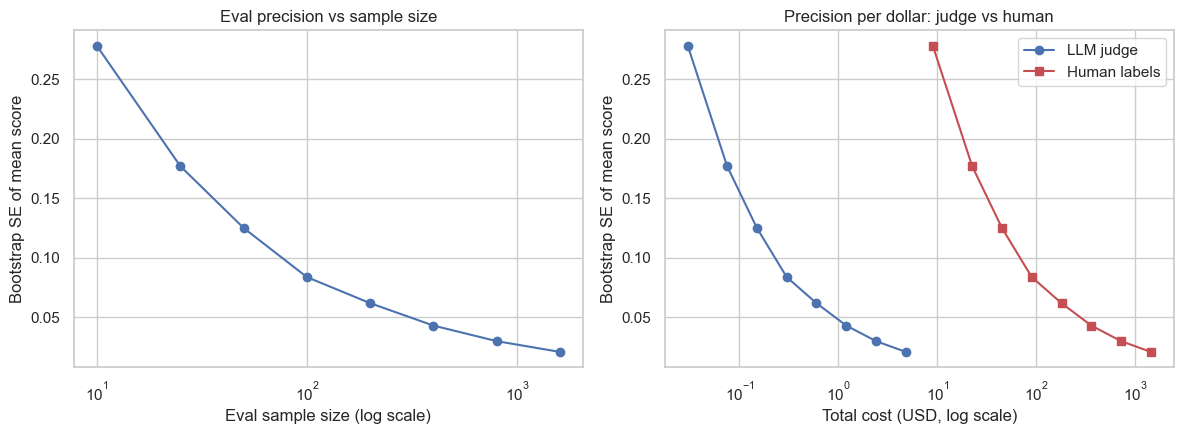

,n_judge_calls,judge_cost_usd,equivalent_human_cost_usd,bootstrap_SE_mean_score
0,10,0.030,9.0,0.2781
1,25,0.075,22.5,0.1769
2,50,0.150,45.0,0.1250
3,100,0.300,90.0,0.0838
4,200,0.600,180.0,0.0619
5,400,1.200,360.0,0.0431
6,800,2.400,720.0,0.0300
7,1600,4.800,1440.0,0.0209


In [12]:
COST_PER_JUDGE_CALL = 0.003
COST_PER_HUMAN_LABEL = 0.90

sample_sizes = [10, 25, 50, 100, 200, 400, 800, 1600]
pareto_rows = []
rng_boot = np.random.default_rng(61)

full_scores = gen_df["judge_score"].to_numpy()

for n in sample_sizes:
    boot_means = []
    for _ in range(400):
        idx = rng_boot.integers(0, len(full_scores), size=n)
        boot_means.append(full_scores[idx].mean())
    se = float(np.std(boot_means, ddof=1))
    pareto_rows.append({
        "n_judge_calls": n,
        "judge_cost_usd": n * COST_PER_JUDGE_CALL,
        "equivalent_human_cost_usd": n * COST_PER_HUMAN_LABEL,
        "bootstrap_SE_mean_score": se,
    })

pareto_df = pd.DataFrame(pareto_rows)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(pareto_df["n_judge_calls"], pareto_df["bootstrap_SE_mean_score"], marker="o", color="#4C72B0")
ax[0].set_xscale("log")
ax[0].set_xlabel("Eval sample size (log scale)")
ax[0].set_ylabel("Bootstrap SE of mean score")
ax[0].set_title("Eval precision vs sample size")

ax[1].plot(pareto_df["judge_cost_usd"], pareto_df["bootstrap_SE_mean_score"], marker="o", color="#4C72B0", label="LLM judge")
ax[1].plot(pareto_df["equivalent_human_cost_usd"], pareto_df["bootstrap_SE_mean_score"], marker="s", color="#C44E52", label="Human labels")
ax[1].set_xscale("log")
ax[1].set_xlabel("Total cost (USD, log scale)")
ax[1].set_ylabel("Bootstrap SE of mean score")
ax[1].set_title("Precision per dollar: judge vs human")
ax[1].legend()

plt.tight_layout()
plt.show()

pareto_df.round(4)


**What to read here.** The SE of the mean falls with √n — doubling sample size cuts the CI width by ~30%. The right-hand panel is the business case: at any target precision, the LLM-judge curve sits roughly 300× to the left of the human curve (because per-call cost is ~300× lower). The implication: for routine regression-style eval, judge calls dominate. For the *calibration* step, human labels remain essential — you only need a few dozen, but the quality of the entire downstream pipeline rests on that small sample.


## 9. Takeaways, limitations, and what a production version would add

**Takeaways**

- RAG evaluation is two loops, not one: a **retrieval loop** (Hit@k, MRR, nDCG) and a **generation loop** (faithfulness, relevance, consistency). Both need to be wired up; most teams under-invest in retrieval and over-rely on eyeballing generation.
- **LLM-as-judge** is not a replacement for humans — it is a scale amplifier on top of a small human-labelled calibration set. The judge's job is to look agreeable *on the calibration set*; extrapolating beyond that requires the judge's calibration to be audited, not assumed.
- **Stratified calibration sampling** matters. A 40-item random sample from production traffic is usually dominated by the majority class and collapses variance in both judge and human scores — making correlation and κ unreliable. Always oversample failure modes.
- Every judge has biases. Three that show up repeatedly: length bias, position bias (in pairwise comparisons), and self-preference bias (models rate their own outputs higher). Detect them in the calibration step; fix them with prompt changes or paired designs.
- Cost arithmetic changes the eval design. At ~$0.003/judge-call vs ~$0.90/human-label, judge calls are the scalable regression harness and humans are the calibration anchor. Both are needed; they are not substitutes.

**Limitations**

- The LLM is simulated. Real models have failure modes (prompt injection, reasoning errors on multi-hop retrieval, inconsistent JSON output) that this notebook cannot reproduce.
- The KB is synthetic and small (60 docs). Production KBs have tens of thousands of docs, messy formatting, competing versions, and stale content — all of which change retrieval and eval results.
- The eval set is synthetic and balanced across difficulty tiers. Real query distributions are long-tailed, and eval sets drawn from production logs need stratification, de-duplication, and privacy review.
- The human simulator has no fatigue, no disagreement between annotators, and no label-drift. Real human eval produces annotator-level variance that inter-rater-reliability metrics (Fleiss' κ, Krippendorff's α) are designed to measure.

**What a production version would add**

- **Real LLM calls** via the Anthropic or OpenAI SDK. The swap is one line — replace `judge_answer` with a function that calls `client.messages.create(...)` and parses a numeric score from the JSON output. Everything downstream (calibration, confusion matrix, cost analysis) stays identical.
- **Prompt-level ablation**: swap the judge prompt between templates (e.g. with/without chain-of-thought, with/without rubric) and compare calibration. This is how you tune the judge itself.
- **Pairwise comparison mode** where the judge decides "A is better than B" rather than scoring on an absolute scale. Usually shows higher human agreement and enables elo-style rankings across systems.
- **Position / self-preference bias detection** via randomised A/B order and cross-model evaluation (e.g. Claude judging outputs from GPT-4 and vice versa).
- **Tracing and replay** (Langfuse / Braintrust / OpenLLMetry) so every judged output is logged with its retrieval context, prompt, and score — essential for retrospective debugging and for building the next calibration set from production traffic.
- **Red-teaming hooks**: adversarial query sets (prompt injection, jailbreak, factual-stress) run as a separate eval track with hard pass/fail thresholds rather than continuous scores.
- **Offline → online bridge**: the final production step is closing the loop by feeding flagged low-score production traffic back into the human-labelled calibration set, on a schedule tied to model / prompt changes.
